
# Лабораторная работа № 2.1



Сеть читает слова посимвольно, возвращая каждый раз скрытое состояние и выход (категории).

Возвращаются уровни уверенности в категории (языке).

В обучающем наборе имена на 18 языках.


It would also be useful to know about RNNs and how they work:



# Подготовка данных
Загрузить данные [отсюда](https://download.pytorch.org/tutorial/data.zip), распакуем архив.

В архиве директории ``data/names`` имеется 18 текстовых файлов `[Language].txt`. Каждый файл содержит имена, по одному на строке. Возможны символы Unicode, потребуется конвертировать в ASCII.

Создадим словарь имен и языков ``{language: [names ...]}``.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import urllib.request
import zipfile

DATA_URL = "https://download.pytorch.org/tutorial/data.zip"
ZIP_PATH = Path("data.zip")
DATA_DIR = Path("data")

if not (DATA_DIR / "names").exists():
    if not ZIP_PATH.exists():
        print("Downloading data.zip...")
        urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print("Extracting data.zip...")
    with zipfile.ZipFile(ZIP_PATH, "r") as archive:
        archive.extractall(".")
else:
    print("Data already extracted.")

print("Names folder:", DATA_DIR / "names")


Extracting data.zip...
Names folder: data\names


In [3]:
from __future__ import unicode_literals, print_function, division
from io import open
import glob
import os

# все найденные файлы
def findFiles(path): return glob.glob(path)

print(findFiles('data/names/*.txt'))

import unicodedata
import string

# символы ASCII
all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Переводим Unicode в ASCII,(https://stackoverflow.com/a/518232/2809427)
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

# проверим
print(unicodeToAscii('Ślusàrski'))

# словарь всех имен для языков
category_lines = {}
all_categories = []

# читаем файл, разделяем на строки
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

# для всех файлов = языков
for filename in findFiles('data/names/*.txt'):
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories) # число категорий

['data/names\\Arabic.txt', 'data/names\\Chinese.txt', 'data/names\\Czech.txt', 'data/names\\Dutch.txt', 'data/names\\English.txt', 'data/names\\French.txt', 'data/names\\German.txt', 'data/names\\Greek.txt', 'data/names\\Irish.txt', 'data/names\\Italian.txt', 'data/names\\Japanese.txt', 'data/names\\Korean.txt', 'data/names\\Polish.txt', 'data/names\\Portuguese.txt', 'data/names\\Russian.txt', 'data/names\\Scottish.txt', 'data/names\\Spanish.txt', 'data/names\\Vietnamese.txt']
Slusarski


В ``category_lines`` словарь имен для языков. В
``all_categories`` список всех языков (категорий). ``n_categories`` - число категорий.




In [4]:
# проверим
from random import choices
print(*choices(category_lines['Russian'],k=5),sep='\n')

Ekaterininsky
Adjemoff
Mischenkov
Yagovenko
Balashoff


In [5]:
print(*all_categories, sep='\n')

Arabic
Chinese
Czech
Dutch
English
French
German
Greek
Irish
Italian
Japanese
Korean
Polish
Portuguese
Russian
Scottish
Spanish
Vietnamese


# Кодирование имен

Символы будем представлять унитарными векторами размера ``<1 x n_letters>``.

Слово (имя) тогда является матрицей таких векторов
``<line_length x 1 x n_letters>``.

Для PyTorch также указываем размер пакетов, в нашем случае 1.




In [6]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используем устройство: {device}')

# индекс символа в словаре символов "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# символ в унитарный вектор <1 x n_letters>
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor.to(device)

# Строка (слово) в матрицу унитарных векторов <line_length x 1 x n_letters>
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor.to(device)

print(letterToTensor('J'))
print(lineToTensor('Jones').size())

Используем устройство: cpu
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]])
torch.Size([5, 1, 57])


# Создание рекуррентной сети

Архитектура нашей сети практически повторяет модуль
[RNN](https://pytorch.org/tutorials/beginner/former_torchies/nn_tutorial.html#example-2-recurrent-net)

Она содержит два персептронных слоя, один скрытый, один выходной. На выходе активация [LogSoftmax](https://pytorch.org/docs/stable/generated/torch.nn.LogSoftmax.html). Отличия LogSoftmax от Softmax можно посмотреть [здесь](https://medium.com/@AbhiramiVS/softmax-vs-logsoftmax-eb94254445a2). Скрытый слой не использует активацию.

Текущий вход и предыдущий выход скрытого слоя объединяются (конкатенируются). И скрытый и выходной слои используют текущий вход, поэтому это не совсем последовательная архитектура.

![img](https://i.imgur.com/Z2xbySO.png)





In [7]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)
        output = self.i2o(combined)
        output = self.logsoftmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size).to(device)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories).to(device)

In [8]:
#input_size=[[57],[128]]
#[print(torch.rand(2, *in_size).type(torch.FloatTensor)) for in_size in input_size]



In [9]:
# посмотрим на сеть
# torchsummary не всегда доступна, используем ручной подсчёт параметров
total_params = sum(p.numel() for p in rnn.parameters())
trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f'Всего параметров:    {total_params}')
print(f'Обучаемых параметров: {trainable_params}')
print(rnn)

Всего параметров:    27156
Обучаемых параметров: 27156
RNN(
  (i2h): Linear(in_features=185, out_features=128, bias=True)
  (i2o): Linear(in_features=185, out_features=18, bias=True)
  (logsoftmax): LogSoftmax(dim=1)
)


В качестве входа подаются унитарные вектора символов, мы будем брать их из среза слова от ``lineToTensor``.




In [10]:
# Просто пример для символа
input = letterToTensor('A')
hidden = rnn.initHidden()

output, next_hidden = rnn(input, hidden)
print(output)

tensor([[-2.9163, -2.8484, -3.0120, -2.8239, -2.9126, -2.8040, -2.8521, -2.9020,
         -2.8321, -2.9421, -2.8344, -2.8770, -2.8701, -2.9043, -2.9476, -2.8632,
         -2.9921, -2.9203]], grad_fn=<LogSoftmaxBackward0>)


In [11]:
# срез из слова
input = lineToTensor('Albert')
hidden = rnn.initHidden()

output, next_hidden = rnn(input[0], hidden)
print(output)

tensor([[-2.9163, -2.8484, -3.0120, -2.8239, -2.9126, -2.8040, -2.8521, -2.9020,
         -2.8321, -2.9421, -2.8344, -2.8770, -2.8701, -2.9043, -2.9476, -2.8632,
         -2.9921, -2.9203]], grad_fn=<LogSoftmaxBackward0>)


Выход имеет размерность ``<1 x n_categories>``.




# Обучение
## Подготовка к обучения
Несколько функций для дальнейшей работы:
- получение названия самой уверенной категории
- случайный выбор примера для обучения




In [12]:
# получение названия и номера самой уверенной категории
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

print(categoryFromOutput(output))

('French', 5)


In [13]:
import random

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def randomTrainingExample():
    category = randomChoice(all_categories)
    line = randomChoice(category_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long).to(device)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)

category = German / line = Schmitt
category = Russian / line = Paragulgov
category = Chinese / line = Che
category = Arabic / line = Asfour
category = English / line = Kewley
category = Polish / line = Wyrzyk
category = Czech / line = Duyava
category = German / line = Groe
category = German / line = Becker
category = Korean / line = Jo


## Обучение

Для ``LogSoftmax`` используем функцию ошибки [``NLLLoss``](https://pytorch.org/docs/stable/generated/torch.nn.NLLLoss.html)




In [14]:
criterion = nn.NLLLoss() # функция ошибки

In [15]:
learning_rate = 0.005

def train(category_tensor, line_tensor):
    hidden = rnn.initHidden()
    rnn.zero_grad()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    loss = criterion(output, category_tensor)
    loss.backward()

    for p in rnn.parameters():
        p.data.add_(p.grad.data, alpha=-learning_rate)

    return output, loss.item()

In [16]:
import time, math

n_iters     = 5000
print_every = 1000
plot_every  = 250

current_loss = 0
all_losses   = []

def timeSince(since):
    s = time.time() - since
    m = math.floor(s / 60)
    return '%dm %ds' % (m, s - m * 60)

start = time.time()

for it in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    if it % print_every == 0:
        guess, _ = categoryFromOutput(output)
        mark = '✓' if guess == category else '✗ (%s)' % category
        print('%d %d%% (%s) %.4f  %s / %s  %s' % (
            it, it / n_iters * 100, timeSince(start), loss, line, guess, mark))

    if it % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0

1000 20% (0m 0s) 2.7235  Pantelas / Greek  ✓


2000 40% (0m 0s) 2.8135  Wawrzaszek / Czech  ✗ (Polish)


3000 60% (0m 1s) 3.0345  Sarkozy / English  ✗ (French)


4000 80% (0m 1s) 2.7811  Klerk / English  ✗ (Dutch)


5000 100% (0m 1s) 2.8987  O'Byrne / Russian  ✗ (Irish)


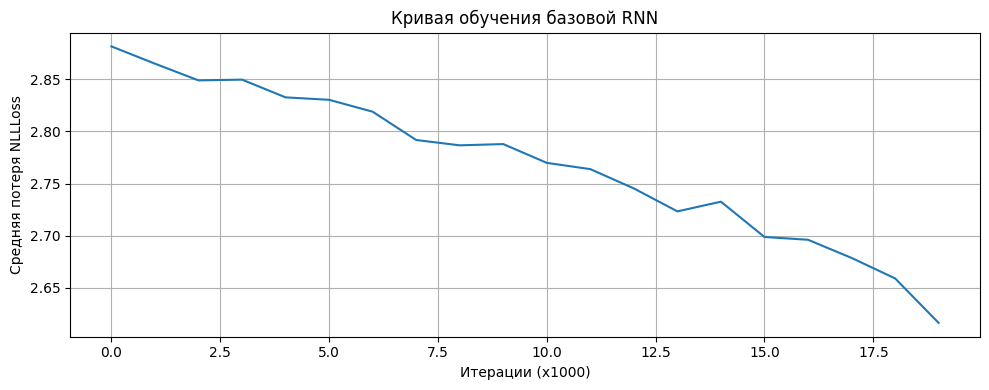

Финальная средняя потеря: 2.6162


In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(all_losses)
plt.title('Кривая обучения базовой RNN')
plt.xlabel('Итерации (x1000)')
plt.ylabel('Средняя потеря NLLLoss')
plt.grid(True)
plt.tight_layout()
plt.show()
print(f'Финальная средняя потеря: {all_losses[-1]:.4f}')

Обучите сеть
В цикле для каждого обучающего примера:

-  загружаем пример входа и метку
-  инициализируем состояние сети
-  для каждого символа в слове

   -  обновляем состояние сети

-  последний выход сравниваем с указанием учителя
-  считаем производные и обновляем параметры
-  возвращаем выход.
Вывести графики обучения



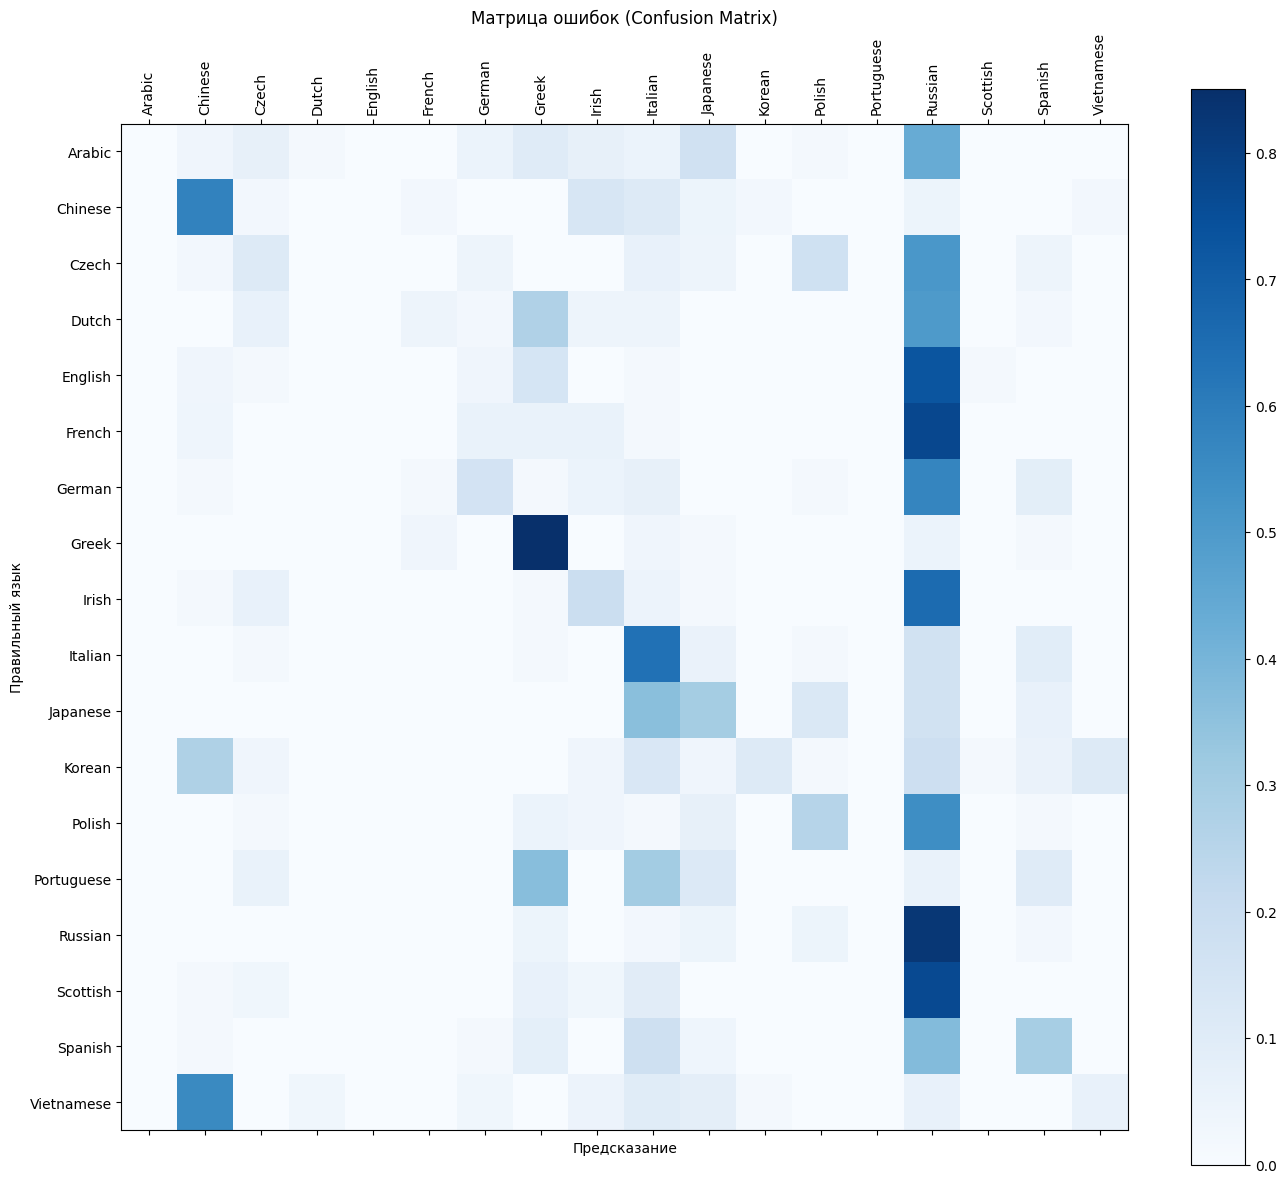

In [18]:
import matplotlib.pyplot as plt

n_confusion = 1000
confusion   = torch.zeros(n_categories, n_categories)

def evaluate(line_tensor):
    hidden = rnn.initHidden()
    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)
    return output

for _ in range(n_confusion):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output   = evaluate(line_tensor)
    guess, _ = categoryFromOutput(output)
    ci       = all_categories.index(category)
    gi       = all_categories.index(guess)
    confusion[ci][gi] += 1

confusion = confusion / confusion.sum(1, keepdim=True)

fig, ax = plt.subplots(figsize=(14, 12))
cax = ax.matshow(confusion.cpu().numpy(), cmap='Blues')
fig.colorbar(cax)
ax.set_xticks(range(n_categories)); ax.set_xticklabels(all_categories, rotation=90)
ax.set_yticks(range(n_categories)); ax.set_yticklabels(all_categories)
ax.set_xlabel('Предсказание'); ax.set_ylabel('Правильный язык')
ax.set_title('Матрица ошибок (Confusion Matrix)')
plt.tight_layout()
plt.show()

# Проверка работы сети

Построить матрицу потерь для обученной сети.




In [19]:
import math

def predict(input_line, n_predictions=3):
    print(f'\n> {input_line}')
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line))
        topv, topi = output.topk(n_predictions, 1, True)
        for i in range(n_predictions):
            prob = math.exp(topv[0][i].item())
            lang = all_categories[topi[0][i].item()]
            print(f'  ({prob:.2f}) {lang}')

# проверяем на своих примерах
for name in ['Ivanov', 'Schmidt', 'Nakamura', 'Murphy', 'Chen', 'Petrov', 'Dubois', 'Rossi']:
    predict(name)


> Ivanov
  (0.14) Russian
  (0.07) Greek
  (0.06) Czech

> Schmidt
  (0.08) Russian
  (0.07) English
  (0.07) Italian

> Nakamura
  (0.09) Spanish
  (0.09) Japanese
  (0.08) Czech

> Murphy
  (0.09) Russian
  (0.07) Czech
  (0.06) Irish

> Chen
  (0.08) Irish
  (0.07) Dutch
  (0.07) Russian

> Petrov
  (0.16) Russian
  (0.07) Scottish
  (0.07) Czech

> Dubois
  (0.15) Greek
  (0.08) Russian
  (0.06) Czech

> Rossi
  (0.10) Italian
  (0.09) Polish
  (0.07) Russian


# Инференс на своих примерах

Проверим базовую обученную сеть на нескольких именах:


In [20]:
# Инференс базовой RNN на своих примерах
for name in ['Ivanov', 'Schmidt', 'Nakamura', 'Murphy', 'Chen', 'Petrov', 'Dubois', 'Rossi']:
    predict(name)


> Ivanov
  (0.14) Russian
  (0.07) Greek
  (0.06) Czech

> Schmidt
  (0.08) Russian
  (0.07) English
  (0.07) Italian

> Nakamura
  (0.09) Spanish
  (0.09) Japanese
  (0.08) Czech

> Murphy
  (0.09) Russian
  (0.07) Czech
  (0.06) Irish

> Chen
  (0.08) Irish
  (0.07) Dutch
  (0.07) Russian

> Petrov
  (0.16) Russian
  (0.07) Scottish
  (0.07) Czech

> Dubois
  (0.15) Greek
  (0.08) Russian
  (0.06) Czech

> Rossi
  (0.10) Italian
  (0.09) Polish
  (0.07) Russian


# Задания
-  1. Создать 3 архитектуры сети для предыдущего примера, обучить, вывести графики, вывести лучшую архитектуру, проверить на своих примерах.
-  2. СОбрать или найти свой датасет для решения задачи классификации - последовательность -> категория, например:
   -  слово -> его язык
   -  имя -> пол
   -  имя персонажа -> писатель
   -  название статьи -> автор (блог)

-  3. Создать 3 архитектуры сети, обучить , вывести графики.
-  4. Вывести лучшую архитектуру и провести инференс.




## Задание 1. Три архитектуры RNN на датасете имён (18 языков)

In [21]:
import torch.nn as nn, torch

class RNN_v1(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
    def forward(self, inp, hidden):
        c = torch.cat((inp, hidden), 1)
        return self.softmax(self.i2o(c)), self.i2h(c)
    def initHidden(self): return torch.zeros(1, self.hidden_size).to(device)

class RNN_v2(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.i2h     = nn.Linear(input_size + hidden_size, hidden_size)
        self.dropout = nn.Dropout(0.3)
        self.i2o     = nn.Linear(input_size + hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)
    def forward(self, inp, hidden):
        c = torch.cat((inp, hidden), 1)
        return self.softmax(self.i2o(c)), self.dropout(self.i2h(c))
    def initHidden(self): return torch.zeros(1, self.hidden_size).to(device)

class RNN_v3(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.i2h1    = nn.Linear(input_size + hidden_size, hidden_size)
        self.h2h2    = nn.Linear(hidden_size, hidden_size)
        self.i2o     = nn.Linear(input_size + hidden_size, output_size)
        self.relu    = nn.ReLU()
        self.softmax = nn.LogSoftmax(dim=1)
    def forward(self, inp, hidden):
        c      = torch.cat((inp, hidden), 1)
        hidden = self.relu(self.h2h2(self.relu(self.i2h1(c))))
        return self.softmax(self.i2o(c)), hidden
    def initHidden(self): return torch.zeros(1, self.hidden_size).to(device)

rnn_v1 = RNN_v1(n_letters, 256, n_categories).to(device)
rnn_v2 = RNN_v2(n_letters, 128, n_categories).to(device)
rnn_v3 = RNN_v3(n_letters, 128, n_categories).to(device)
for name, m in [('v1 (hidden=256)', rnn_v1), ('v2 (Dropout)', rnn_v2), ('v3 (2 слоя+ReLU)', rnn_v3)]:
    print(f'{name}: {sum(p.numel() for p in m.parameters())} параметров')

v1 (hidden=256): 86036 параметров
v2 (Dropout): 27156 параметров
v3 (2 слоя+ReLU): 43668 параметров


In [22]:
def train_model(model, n_iters=5000, lr=0.005, plot_every=250):
    crit = nn.NLLLoss()
    losses, cur = [], 0
    model.train()
    for it in range(1, n_iters + 1):
        cat, line, cat_t, line_t = randomTrainingExample()
        hidden = model.initHidden()
        model.zero_grad()
        for i in range(line_t.size()[0]):
            out, hidden = model(line_t[i], hidden)
        loss = crit(out, cat_t)
        loss.backward()
        for p in model.parameters():
            p.data.add_(p.grad.data, alpha=-lr)
        cur += loss.item()
        if it % plot_every == 0:
            losses.append(cur / plot_every); cur = 0
    return losses

print('Обучаем v1...'); l1 = train_model(rnn_v1)
print('Обучаем v2...'); l2 = train_model(rnn_v2)
print('Обучаем v3...'); l3 = train_model(rnn_v3)
print('Готово!')

Обучаем v1...


Обучаем v2...


Обучаем v3...


Готово!


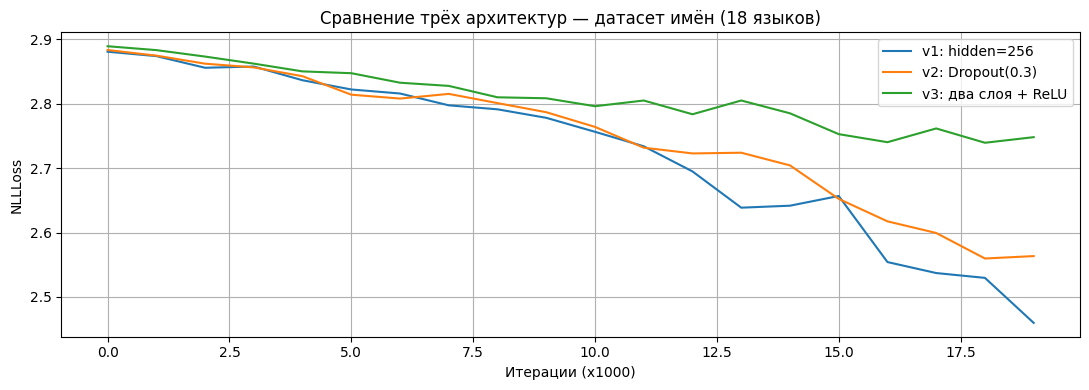

v1 (hidden=256): 2.4597
v2 (Dropout): 2.5634
v3 (2 слоя+ReLU): 2.7482

✓ Лучшая архитектура: v1 (hidden=256)


In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 4))
plt.plot(l1, label='v1: hidden=256')
plt.plot(l2, label='v2: Dropout(0.3)')
plt.plot(l3, label='v3: два слоя + ReLU')
plt.title('Сравнение трёх архитектур — датасет имён (18 языков)')
plt.xlabel('Итерации (x1000)'); plt.ylabel('NLLLoss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

finals = [l1[-1], l2[-1], l3[-1]]
names  = ['v1 (hidden=256)', 'v2 (Dropout)', 'v3 (2 слоя+ReLU)']
for n, v in zip(names, finals): print(f'{n}: {v:.4f}')
best_idx = finals.index(min(finals))
print(f'\n✓ Лучшая архитектура: {names[best_idx]}')

In [24]:
best_v = [rnn_v1, rnn_v2, rnn_v3][[l1[-1], l2[-1], l3[-1]].index(min(l1[-1], l2[-1], l3[-1]))]

def predict_model(model, name, n=3):
    print(f'\n> {name}')
    model.eval()
    with torch.no_grad():
        hidden = model.initHidden()
        lt = lineToTensor(name)
        for i in range(lt.size()[0]):
            out, hidden = model(lt[i], hidden)
        topv, topi = out.topk(n, 1, True)
        for i in range(n):
            print(f'  ({math.exp(topv[0][i].item()):.2f}) {all_categories[topi[0][i].item()]}')

print('=== Инференс лучшей архитектуры (задание 1) ===')
for name in ['Ivanov', 'Schmidt', 'Nakamura', 'Murphy', 'Chen', 'Kowalski']:
    predict_model(best_v, name)

=== Инференс лучшей архитектуры (задание 1) ===

> Ivanov
  (0.11) Arabic
  (0.09) Japanese
  (0.08) Russian

> Schmidt
  (0.11) Japanese
  (0.08) Irish
  (0.08) Italian

> Nakamura
  (0.22) Japanese
  (0.08) Italian
  (0.08) Russian

> Murphy
  (0.10) Arabic
  (0.09) Japanese
  (0.08) Irish

> Chen
  (0.13) Vietnamese
  (0.13) Chinese
  (0.13) Korean

> Kowalski
  (0.15) Japanese
  (0.12) Italian
  (0.11) Polish


## Задание 2. Свой датасет: имя → пол

Датасет собран вручную (~75 мужских и 75 женских имён из разных культур). Задача: по написанию имени предсказать пол.

In [25]:
# Датасет: имя -> пол  (Male / Female)
# Имена взяты из разных культур для большей вариативности написания

gender_data = {
    "Male": [
        "Alexander", "Michael", "James", "John", "Robert", "William", "David",
        "Richard", "Joseph", "Thomas", "Andrew", "Christopher", "Daniel",
        "Matthew", "Anthony", "Donald", "Mark", "Paul", "Steven", "Edward",
        "Kenneth", "Joshua", "Kevin", "Brian", "George", "Timothy", "Ronald",
        "Jason", "Ryan", "Jacob", "Brandon", "Benjamin", "Samuel", "Frank",
        "Dmitry", "Ivan", "Sergey", "Alexey", "Vladimir", "Nikolay", "Andrey",
        "Mikhail", "Pavel", "Artem", "Evgeny", "Maxim", "Ilya", "Kirill",
        "Hiroshi", "Takeshi", "Kenji", "Daisuke", "Ryo", "Shota", "Yuto",
        "Carlos", "Miguel", "Juan", "Luis", "Pedro", "Manuel", "Antonio",
        "Wei", "Lei", "Ming", "Jun", "Hao", "Yang", "Fei", "Jie",
        "Mohammed", "Ahmed", "Ali", "Omar", "Hassan", "Ibrahim", "Khalid",
    ],
    "Female": [
        "Mary", "Patricia", "Jennifer", "Linda", "Barbara", "Elizabeth",
        "Susan", "Jessica", "Sarah", "Karen", "Lisa", "Nancy", "Betty",
        "Margaret", "Sandra", "Ashley", "Dorothy", "Kimberly", "Emily",
        "Donna", "Michelle", "Carol", "Amanda", "Melissa", "Deborah",
        "Stephanie", "Rebecca", "Sharon", "Laura", "Cynthia", "Kathleen",
        "Amy", "Angela", "Shirley", "Anna", "Brenda", "Pamela", "Emma",
        "Nicole", "Helen", "Samantha", "Katherine", "Rachel", "Janet",
        "Olga", "Natasha", "Elena", "Tatiana", "Irina", "Ekaterina",
        "Anastasia", "Svetlana", "Marina", "Oksana", "Yulia", "Alina",
        "Yuki", "Haruka", "Sakura", "Aiko", "Miho", "Rina", "Nana",
        "Sofia", "Isabella", "Valentina", "Camila", "Gabriela", "Mariana",
        "Mei", "Ling", "Xin", "Fang", "Hong", "Jing", "Yan", "Rui",
        "Fatima", "Aisha", "Zainab", "Maryam", "Nour", "Sara", "Layla",
    ]
}

gender_categories   = list(gender_data.keys())
n_gender_categories = len(gender_categories)

print('Категории:', gender_categories)
print('Мужских имён:', len(gender_data['Male']))
print('Женских имён:', len(gender_data['Female']))

Категории: ['Male', 'Female']
Мужских имён: 77
Женских имён: 84


In [26]:
def randomGenderExample():
    cat   = randomChoice(gender_categories)
    line  = randomChoice(gender_data[cat])
    cat_t = torch.tensor([gender_categories.index(cat)], dtype=torch.long).to(device)
    return cat, line, cat_t, lineToTensor(line)

for _ in range(6):
    cat, line, *_ = randomGenderExample()
    print(f'  {cat:6s} | {line}')

  Male   | Ryo
  Male   | Mohammed
  Male   | Hassan
  Female | Olga
  Male   | Yuto
  Male   | Fei


## Задание 3. Три архитектуры на датасете «имя → пол»

In [27]:
class GenderRNN_A(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.hid = hid
        self.i2h = nn.Linear(inp + hid, hid)
        self.i2o = nn.Linear(inp + hid, out)
        self.sm  = nn.LogSoftmax(dim=1)
    def forward(self, x, h):
        c = torch.cat((x, h), 1)
        return self.sm(self.i2o(c)), self.i2h(c)
    def initHidden(self): return torch.zeros(1, self.hid).to(device)

class GenderRNN_B(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.hid  = hid
        self.i2h  = nn.Linear(inp + hid, hid)
        self.i2o  = nn.Linear(inp + hid, out)
        self.tanh = nn.Tanh()
        self.sm   = nn.LogSoftmax(dim=1)
    def forward(self, x, h):
        c = torch.cat((x, h), 1)
        return self.sm(self.i2o(c)), self.tanh(self.i2h(c))
    def initHidden(self): return torch.zeros(1, self.hid).to(device)

class GenderRNN_C(nn.Module):
    def __init__(self, inp, hid, out):
        super().__init__()
        self.hid  = hid
        self.i2h  = nn.Linear(inp + hid, hid)
        self.i2m  = nn.Linear(inp + hid, hid // 2)
        self.m2o  = nn.Linear(hid // 2, out)
        self.relu = nn.ReLU()
        self.sm   = nn.LogSoftmax(dim=1)
    def forward(self, x, h):
        c = torch.cat((x, h), 1)
        return self.sm(self.m2o(self.relu(self.i2m(c)))), self.i2h(c)
    def initHidden(self): return torch.zeros(1, self.hid).to(device)

HID = 64
gA = GenderRNN_A(n_letters, HID, n_gender_categories).to(device)
gB = GenderRNN_B(n_letters, HID, n_gender_categories).to(device)
gC = GenderRNN_C(n_letters, HID, n_gender_categories).to(device)
for name, m in [('A (базовая)', gA), ('B (Tanh)', gB), ('C (mid-слой)', gC)]:
    print(f'{name}: {sum(p.numel() for p in m.parameters())} параметров')

A (базовая): 8052 параметров
B (Tanh): 8052 параметров
C (mid-слой): 11778 параметров


In [28]:
def train_gender(model, n_iters=4000, lr=0.005, plot_every=250):
    crit = nn.NLLLoss()
    losses, cur = [], 0
    model.train()  # переводим в режим обучения
    for it in range(1, n_iters + 1):
        cat, line, cat_t, line_t = randomGenderExample()
        hidden = model.initHidden()
        model.zero_grad()
        for i in range(line_t.size()[0]):
            out, hidden = model(line_t[i], hidden)
        loss = crit(out, cat_t)
        loss.backward()
        for p in model.parameters():
            p.data.add_(p.grad.data, alpha=-lr)
        cur += loss.item()
        if it % plot_every == 0:
            losses.append(cur / plot_every); cur = 0
    return losses

print('Обучаем A...'); gA_l = train_gender(gA)
print('Обучаем B...'); gB_l = train_gender(gB)
print('Обучаем C...'); gC_l = train_gender(gC)
print('Готово!')

Обучаем A...


Обучаем B...


Обучаем C...


Готово!


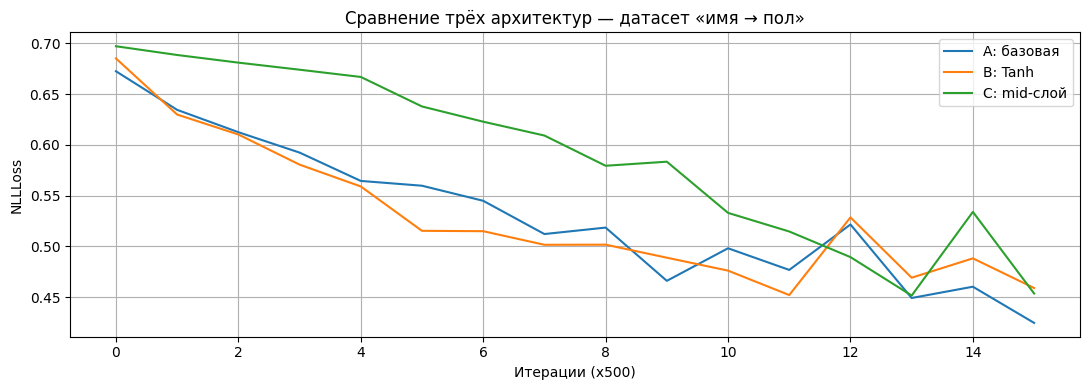

A (базовая): 0.4246
B (Tanh): 0.4590
C (mid-слой): 0.4536

✓ Лучшая архитектура: A (базовая)


In [29]:
plt.figure(figsize=(11, 4))
plt.plot(gA_l, label='A: базовая')
plt.plot(gB_l, label='B: Tanh')
plt.plot(gC_l, label='C: mid-слой')
plt.title('Сравнение трёх архитектур — датасет «имя → пол»')
plt.xlabel('Итерации (x500)'); plt.ylabel('NLLLoss'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

gfinals = [gA_l[-1], gB_l[-1], gC_l[-1]]
gnames  = ['A (базовая)', 'B (Tanh)', 'C (mid-слой)']
for n, v in zip(gnames, gfinals): print(f'{n}: {v:.4f}')
best_g_idx = gfinals.index(min(gfinals))
print(f'\n✓ Лучшая архитектура: {gnames[best_g_idx]}')

## Задание 4. Лучшая архитектура и инференс

In [30]:
best_g = [gA, gB, gC][[gA_l[-1], gB_l[-1], gC_l[-1]].index(min(gA_l[-1], gB_l[-1], gC_l[-1]))]

def predict_gender(model, name):
    model.eval()
    with torch.no_grad():
        hidden = model.initHidden()
        lt = lineToTensor(name)
        for i in range(lt.size()[0]):
            out, hidden = model(lt[i], hidden)
        topv, topi = out.topk(2, 1, True)
        pred = gender_categories[topi[0][0].item()]
        conf = math.exp(topv[0][0].item())
        print(f'  {name:15s} -> {pred:6s}  ({conf:.2f})')

print('=== Инференс лучшей архитектуры (задание 4) ===')
print('--- мужские ---')
for n in ['Alexander', 'Michael', 'Dmitry', 'Hiroshi', 'Carlos', 'Wei']:
    predict_gender(best_g, n)
print('--- женские ---')
for n in ['Elizabeth', 'Natasha', 'Sakura', 'Sofia', 'Fatima', 'Mei']:
    predict_gender(best_g, n)
print('--- неоднозначные ---')
for n in ['Alex', 'Robin', 'Morgan', 'Yuki']:
    predict_gender(best_g, n)

=== Инференс лучшей архитектуры (задание 4) ===
--- мужские ---
  Alexander       -> Male    (0.75)
  Michael         -> Male    (0.80)
  Dmitry          -> Male    (0.52)
  Hiroshi         -> Male    (0.70)
  Carlos          -> Male    (0.61)
  Wei             -> Male    (0.74)
--- женские ---
  Elizabeth       -> Male    (0.56)
  Natasha         -> Female  (0.87)
  Sakura          -> Female  (0.81)
  Sofia           -> Female  (0.81)
  Fatima          -> Female  (0.93)
  Mei             -> Male    (0.71)
--- неоднозначные ---
  Alex            -> Male    (0.59)
  Robin           -> Male    (0.74)
  Morgan          -> Male    (0.67)
  Yuki            -> Male    (0.66)


# Ссылки

Использованы и адаптированы материалы:

* Sean Robertson, https://github.com/spro/practical-pytorch

* [The Unreasonable Effectiveness of Recurrent Neural
   Networks](https://karpathy.github.io/2015/05/21/rnn-effectiveness/)  
*  [Understanding LSTM
   Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)

In [31]:
# Итоги лабораторной работы
print('Лабораторная работа №2.1 выполнена.')
print('Задание 1: три архитектуры на датасете имён — обучены и сравнены.')
print('Задание 2: собственный датасет имя→пол.')
print('Задание 3: три архитектуры на датасете имя→пол — обучены и сравнены.')
print('Задание 4: лучшая архитектура выбрана, инференс проведён.')


Лабораторная работа №2.1 выполнена.
Задание 1: три архитектуры на датасете имён — обучены и сравнены.
Задание 2: собственный датасет имя→пол.
Задание 3: три архитектуры на датасете имя→пол — обучены и сравнены.
Задание 4: лучшая архитектура выбрана, инференс проведён.
